# Подготовка анализа записей эпох с пилотного эксперимента марта-апреля 2026 (исследование разных фаз, представление - покой)

Цель:
- Проверить структуру файлов с эпохами
- Посмотреть на данные
- Подготовить функции для анализа всех данных

Dataset: D:\temp\ICA\Cleaned_epochs (компьютер ТМС-ный) <br>
Date: 2026-04-16

In [1]:
# === project setup ===
from pathlib import Path
import sys

PROJECT_ROOT = Path().resolve().parents[0]
print("PROJECT_ROOT =", PROJECT_ROOT)

if not (PROJECT_ROOT / "src").exists():
    raise RuntimeError("src directory not found — wrong PROJECT_ROOT")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT = C:\Users\hodor\Documents\lab-MSU\Works\2025.10_TMS\TEP_analysis


In [2]:
# === imports ===
import pandas as pd 
import numpy as np 
from h5py import File
import json
import os 

# graphics
import matplotlib.pyplot as plt 
import seaborn as sns
from mne.viz import plot_topomap
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec

In [3]:
from src.utils.montage_processing import *

In [4]:
# === config ===
# data_folder = r"D:\2025 - TEP\data - trans\CLEAN_EPOCHS"
data_folder = r"..\data\pilot\MI_SMA_phases_v2"
records = os.listdir(data_folder)
# records = [record for record in records if record.find("projectionMatrix") == -1 and record.find("png") == -1 and record.find("28") == -1]

In [5]:
df_metadata = pd.read_csv("../resources/TEP_dataset.csv")
df_metadata = df_metadata[["sessionID", "setID", "ParticipantName", "spot", "angle_yaw", "Task"]]
df_metadata = df_metadata.loc[df_metadata.sessionID >= 29]
df_metadata[-10:]

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
184,34,5,Бердышев Даниил,SMA,90,SST
185,34,6,Бердышев Даниил,SMA,90,SST
186,34,7,Бердышев Даниил,M1-right,45,MI
187,35,1,Васильев Анатолий,SMA,90,MI
188,35,2,Васильев Анатолий,M1,45,MI
189,35,3,Васильев Анатолий,M1-shift,45,MI
190,35,4,Васильев Анатолий,M1-right,45,MI
191,35,5,Васильев Анатолий,M1,-135,MI
192,35,6,Васильев Анатолий,M1,45,MI
193,35,7,Васильев Анатолий,SMA,90,MI


In [6]:
filename_colors = r"../resources/channel_colors.json"
with open(filename_colors, "r") as f:
    EEG64_REGION_COLOR = json.load(f)
CED_FILE = r"../resources/mks64_standard.ced"
df = pd.read_csv(CED_FILE, sep='\t')
df["colors"] = df["labels"].map(EEG64_REGION_COLOR)
colors = df["colors"].values
positions = get_topo_positions(CED_FILE)

In [7]:
ROI_contra = ["C3", "C5", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

In [8]:
Fs = 5000
ms_to_s = lambda x: int(Fs * x / 1000)

In [9]:
record = records[0]
filename = os.path.join(data_folder, record)

def get_data(filename):
    with File(filename, "r") as h5f:
        epochs = h5f["data"]["Epruned"][:]
        tvec = h5f["data"]["tvec"][:]
        conds = h5f["data"]["conds"][:]
    return epochs, tvec, conds

epochs, tvec, conds = get_data(filename)

print(f"Выбранный файл: {filename}")
print(f"Epochs shape: {epochs.shape}")

Выбранный файл: ..\data\pilot\MI_SMA_phases_v2\session_29__set_1.h5
Epochs shape: (3501, 72, 64)


In [11]:
def find_records(records, df, tasks=None, spot=None, angle=None, participant=None):
    df_curr = df.copy()
    if participant is not None:
        df_curr = df_curr.loc[(df_curr.ParticipantName == participant)]
    if tasks is not None:
        df_curr = df_curr.loc[(df_curr.Task.isin(tasks))]
    if spot is not None:
        df_curr = df_curr.loc[(df_curr.spot == spot)]
    if angle is not None:
        df_curr = df_curr.loc[(df_curr.angle_yaw == angle)]
    
    new_records = []
    for row in df_curr.itertuples():
        record = [record for record in records if record.find(f"session_{row.sessionID}__set_{row.setID}") != -1][0]
        new_records.append(record)
    return df_curr, new_records

tasks = ["MI", "real"]
spot = "M1-right"
angle = "45"
participant="Васильев Анатолий"

df_task, task_records = find_records(records, df_metadata, tasks, spot, angle=None, participant=None)
df_task.shape

(3, 6)

In [12]:
df_task

,sessionID,setID,ParticipantName,spot,angle_yaw,Task
177,33,7,Васильев Анатолий,M1-right,-135,MI
186,34,7,Бердышев Даниил,M1-right,45,MI
190,35,4,Васильев Анатолий,M1-right,45,MI


# functions

In [13]:
def get_conditions_masks(conds):
    before_mask = conds[:, 0].astype(bool)
    onset_mask = conds[:, 1].astype(bool)
    rest_mask = conds[:, 2].astype(bool)
    return before_mask, onset_mask, rest_mask

In [14]:
# элементарное нахождение характеристик пика в заданных критериях
def find_peak_amp(tlim, tvec, epochs, func):
    mask = np.where((tvec > tlim[0]) & (tvec < tlim[1]))[0]
    peak = epochs[:, mask]
    peak_amp = func(peak)
    return peak_amp

def get_mask(tlim, tvec):
    mask = np.where((tvec > tlim[0]) & (tvec < tlim[1]))[0]
    idx_start = np.where(tvec == tlim[0])[0][0]
    return mask, idx_start

In [15]:
def get_record_name(session, set):
    return f"session_{session}__set_{set}.h5"

In [16]:
def normalize(data):
    # data (samples, epochs, channels)
    normalized = np.zeros_like(data)
    
    min_val = np.min(data)
    max_val = np.max(data)
    
    if max_val - min_val > 0:
        normalized = (data - min_val) / (max_val - min_val)
    else:
        normalized = data
    
    return normalized

In [17]:
def normalize_per_trial(data):
    # data (samples, epochs, channels)
    normalized = np.zeros_like(data)
    
    for trial in range(data.shape[1]):
        for ch in range(data.shape[2]):
            traj = data[:, trial, ch]
            min_val = np.min(traj)
            max_val = np.max(traj)
            
            if max_val - min_val > 0:
                normalized[:, trial, ch] = (traj - min_val) / (max_val - min_val)
            else:
                normalized[:, trial, ch] = traj
    
    return normalized

# Усреднение записей

In [18]:
set2avg = []
for part in df_task.ParticipantName.unique():
    ses = df_task.loc[df_task.ParticipantName == part].sessionID.values
    sets = df_task.loc[df_task.ParticipantName == part].setID.values
    print(part, list(zip(ses, sets)))
    set2avg.append(list(zip(ses, sets)))
set2avg

Васильев Анатолий [(np.int64(33), np.int64(7)), (np.int64(35), np.int64(4))]
Бердышев Даниил [(np.int64(34), np.int64(7))]


[[(np.int64(33), np.int64(7)), (np.int64(35), np.int64(4))],
 [(np.int64(34), np.int64(7))]]

In [19]:
epochs = []

# усреднять по людям
for recs in set2avg:
    ep_pers = [[], [], []]
    for rec in recs:
        record = get_record_name(rec[0], rec[1])
        filename = os.path.join(data_folder, record)
        epochs_all, tvec, conds = get_data(filename)
        # epochs_all_norm = normalize(epochs_all)

        before_mask, onset_mask, rest_mask = get_conditions_masks(conds)

        ep_pers[0].append(epochs_all[:, before_mask, :])
        ep_pers[1].append(epochs_all[:, onset_mask, :])
        ep_pers[2].append(epochs_all[:, rest_mask, :])
    ep_pers = np.array(ep_pers)
    epochs.append(np.mean(ep_pers, axis=(1, 3)))        # усредняем внутри человека и по эпохам -> TEPs
TEPs = np.array(epochs)
TEPs.shape  # (n_part, n_cond, n_samples, n_channels)

(2, 3, 3501, 64)

# Подсчёт характеристик пиков

In [201]:
ROI_N20 = ["C5", "C3", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_P60 = ["C3", "C1", "CP3",  "CP1", "P3", "P1"]
ROI_ipsi = ["FCz", "Cz", "CPz", "FC2", "C2", "CP2", "C4", "CP4"]
ROI_100 = [ "C3", "C1", "CP3",  "CP1", "FC3", "FC1", "FCz", "Cz", "CPz", "FC2", "C2", "C4", "F1", "Fz"]

In [162]:
def create_pandas(amps, amp_idxs):
    df_concat = []
    conds = ["before", "onset", "rest"]
    for i in [0, 1, 2]:
        values = amps[:, i]
        df_concat.append(pd.DataFrame({
            "participant": df_task.ParticipantName.unique(), 
            "subject": [f"исп_{j}" for j in [1, 2, 3, 4]], 
            "amps": values, 
            "lats": [tvec[idx][0] for idx in amp_idxs[:, i]], 
            "conds": [conds[i]] * 4, 
            "conds_n": [i] * 4
        }))
    df_amp = pd.concat(df_concat, ignore_index=True)
    return df_amp

In [193]:
def find_amps(tlim, TEPs, ROI, peak="min"):
    mask, idx_start = get_mask(tlim, tvec)

    idxs = [find_ch_idx(ch, CED_FILE) for ch in ROI]
    mean_tep = np.mean(TEPs[:, :, :, idxs], axis=3)      # усреднение по переданным каналам
    roi_tep = mean_tep[:, :, mask]                      # среднее ТВП в области tlim
    
    fun_amp = lambda x: np.min(x, axis=2) if peak == "min" else np.max(roi_tep, axis=2)
    fun_lat = lambda x: np.argmin(x, axis=2) if peak == "min" else np.argmax(roi_tep, axis=2)  
    amps = fun_amp(roi_tep)                      # амплитуда пика для каждого человека
    idx = idx_start + fun_lat(roi_tep)                       # расположение пика для каждого человека
    
    return amps, idx

def plot_amps(df_amp, metric, title):
    plt.figure(figsize=(3, 5))
    sns.scatterplot(df_amp, x="conds_n", y=metric,  hue="subject", style="subject", markers=True, s=200,palette="dark")
    plt.xlim(-0.2, 2.2)
    plt.ylabel("амплитуда [мкВ]", fontsize=14)
    plt.yticks(fontsize=12)
    plt.xticks([0, 1, 2], ["до", "во время","покой"], fontsize=12)
    plt.xlabel("")
    plt.legend(loc=[1.01, 0.75])
    plt.title(title, fontsize=16)
    plt.grid()

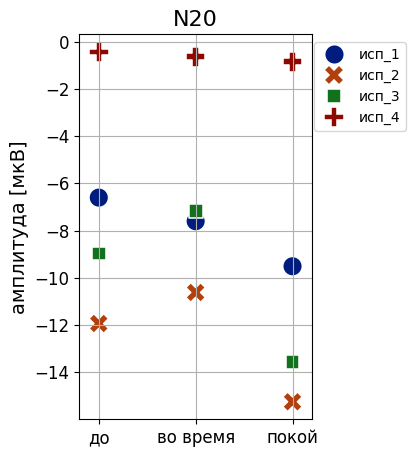

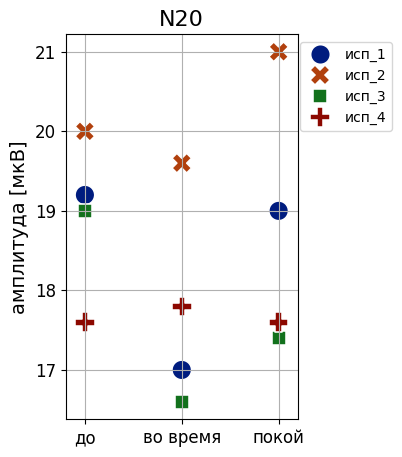

In [194]:
# N20 
tlim = [15, 25]
amps, amp_idxs = find_amps(tlim, TEPs, ROI_N20, peak="min")
df_amp = create_pandas(amps, amp_idxs)
plot_amps(df_amp, metric="amps", title="N20")
plot_amps(df_amp, metric="lats", title="N20")

(15.0, 23.0)

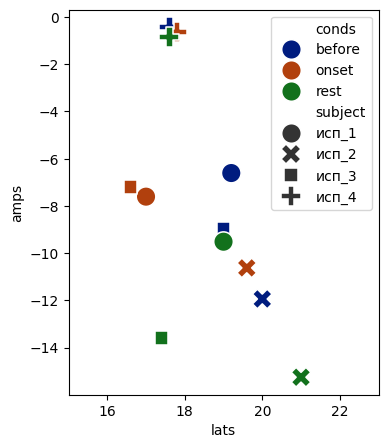

In [186]:
plt.figure(figsize=(4, 5))
sns.scatterplot(df_amp, x="lats", y="amps",  hue="conds", style="subject", markers=True, s=200,palette="dark")
plt.xlim(15, 23)

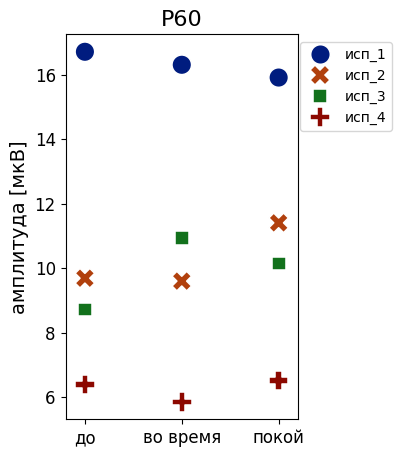

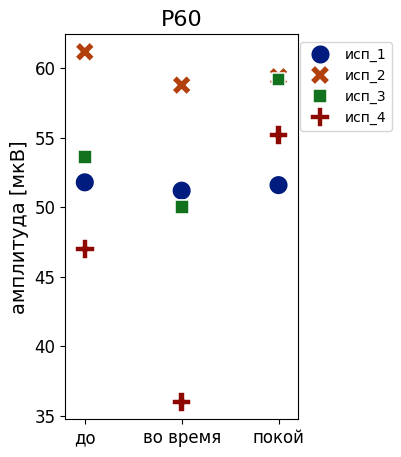

In [191]:
# P60 
tlim = [35, 75]
amps, amp_idxs = find_amps(tlim, TEPs, ROI_P60, peak="max")
df_amp = create_pandas(amps, amp_idxs)
plot_amps(df_amp, "amps", title="P60")
plot_amps(df_amp, "lats", title="P60")

<Axes: xlabel='lats', ylabel='amps'>

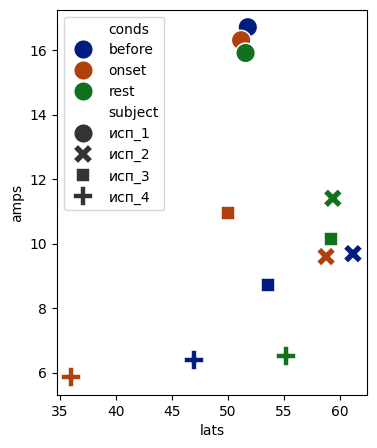

In [190]:
plt.figure(figsize=(4, 5))
sns.scatterplot(df_amp, x="lats", y="amps",  hue="conds", style="subject", markers=True, s=200,palette="dark")
# plt.xlim(15, 23)

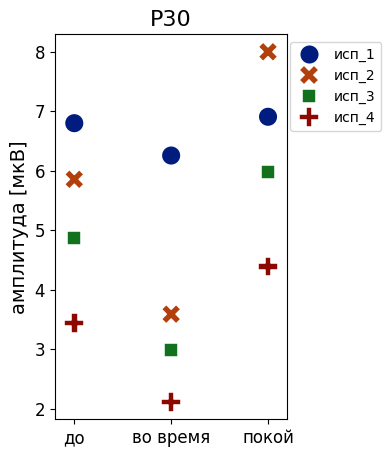

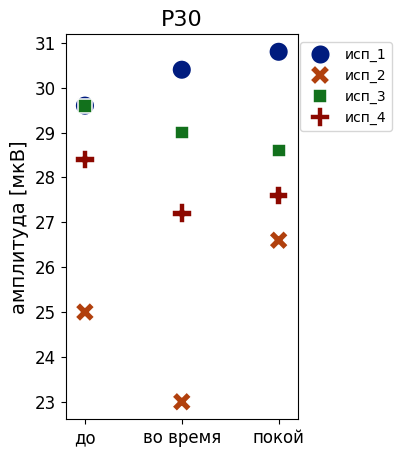

In [192]:
# P30 
tlim = [23, 37]
amps, amp_idxs = find_amps(tlim, TEPs, ROI_ipsi, peak="max")
df_amp = create_pandas(amps, amp_idxs)
plot_amps(df_amp, "amps", title="P30")
plot_amps(df_amp, "lats", title="P30")

In [139]:
df_amp

,participant,subject,amps,conds,conds_n
0,Пономорёв Тимофей,исп_1,3.988807,before,0
1,Васильев Анатолий,исп_2,2.274619,before,0
2,Мирошников Андрей,исп_3,0.341321,before,0
3,Бердышев Даниил,исп_4,0.677967,before,0
4,Пономорёв Тимофей,исп_1,3.681242,onset,1
5,Васильев Анатолий,исп_2,0.597852,onset,1
6,Мирошников Андрей,исп_3,-1.470927,onset,1
7,Бердышев Даниил,исп_4,-0.260089,onset,1
8,Пономорёв Тимофей,исп_1,4.293693,rest,2
9,Васильев Анатолий,исп_2,3.530902,rest,2


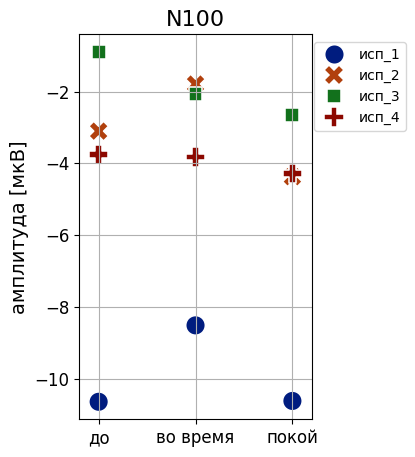

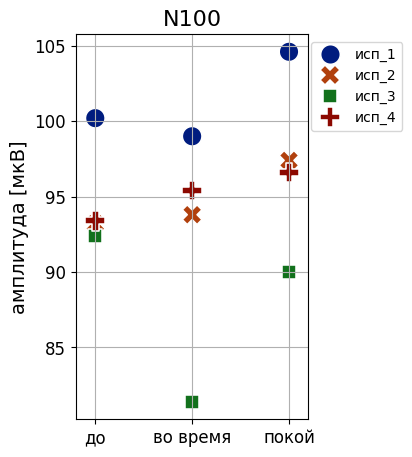

In [204]:
# MN100
tlim = [80, 120]
amps, amp_idxs = find_amps(tlim, TEPs, ROI_ipsi, peak="min")
df_amp = create_pandas(amps, amp_idxs)
plot_amps(df_amp, "amps", title="N100")
plot_amps(df_amp, "lats", title="N100")

In [19]:
# N20 
tlim = [15, 25]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.min(epochs_peak, axis=(2, 3))

amps

array([[-11.232791, -11.896632, -15.553581],
       [-20.636013, -18.965002, -26.383635],
       [-14.217751, -11.294953, -21.709934],
       [ -5.868569,  -6.98557 ,  -7.048198]], dtype=float32)

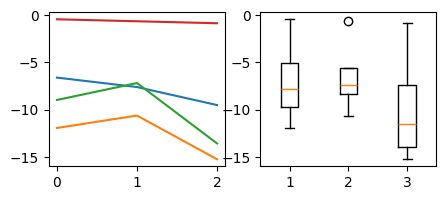

In [79]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

In [21]:
# P60
tlim = [45, 75]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.max(epochs_peak, axis=(2, 3))

amps

array([[20.255644, 19.943605, 19.957575],
       [13.401765, 13.12639 , 15.99649 ],
       [11.102439, 14.805603, 12.618938],
       [ 8.325441,  8.950048,  8.646262]], dtype=float32)

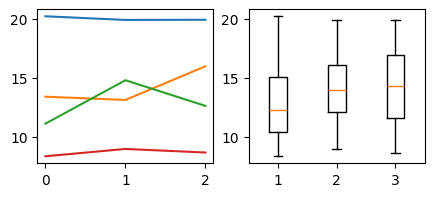

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

In [23]:
# N100
tlim = [80, 110]
mask = get_mask(tlim, tvec)

epochs_peak = TEPs[:, :, mask, :]
amps = np.min(epochs_peak, axis=(2, 3))

amps

array([[-16.952148 , -12.812396 , -17.120264 ],
       [ -9.014147 ,  -7.357751 , -10.634923 ],
       [ -4.830107 ,  -5.7129183,  -9.68176  ],
       [ -6.829265 ,  -7.4685326,  -6.90788  ]], dtype=float32)

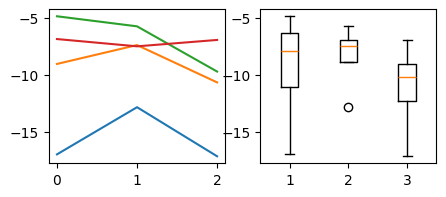

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(5, 2))
ax[0].plot(amps.T);
# ax[0].yscale('symlog', linthresh=0.1)  # <- используйте это!
ax[1].boxplot(amps);

# Усреднённые данные

In [20]:
TEPs.shape

(2, 3, 3501, 64)

In [21]:
epochs_avr = np.mean(TEPs, axis=0)  # усреднение по людям
epochs_avr.shape

(3, 3501, 64)

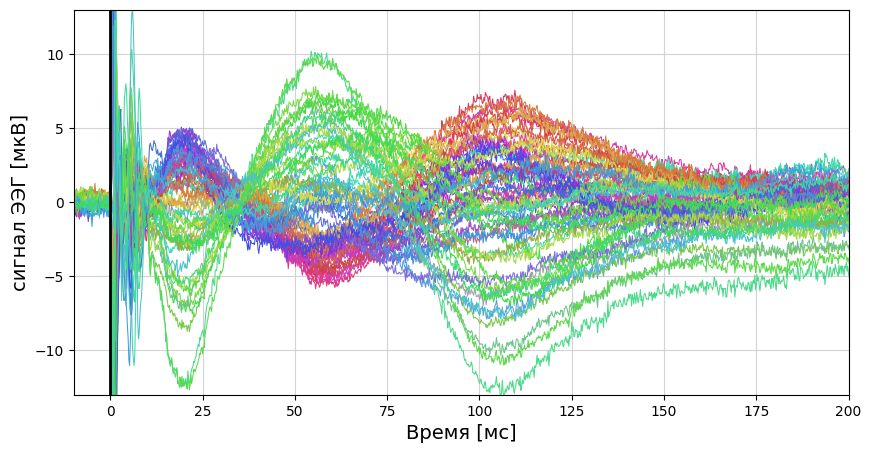

In [22]:
tmin, tmax = -10, 200
amp = 13

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

TEPs_avr_all = np.mean(epochs_avr, axis=0)
for color, TEP in zip(colors, TEPs_avr_all.T): # начало движения
    ax.plot(tvec, TEP, color=color, linewidth=.75)
ax.set_xlim(tmin, tmax)
ax.set_ylim(-amp, amp)
ax.set_xlabel("Время [мс]", fontsize=14)
ax.set_ylabel("сигнал ЭЭГ [мкВ]", fontsize=14)
ax.grid(color="lightgrey")

# ax.set_title('ТВП в М1 в момент выполнения движения', fontsize=18)

ax.axvline(0, color="black", linewidth=2)

In [23]:
def plot_butterfly(tep, tmin, tmax, tlim, amp, ROI_channnels, ax, xlabel, ylabel, title, labels=False):
    mask_interest = ((tvec >= tlim[0]) & (tvec <= tlim[1])).flatten()

    ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_channnels]

    alpha = np.array([0.3] * epochs_avr.shape[2])
    alpha[ROI_idx] = 1

    width = np.array([.6] * epochs_avr.shape[2])
    width[ROI_idx] = 1.2

    lines = []
    ch = 0
    for color, TEP in zip(colors, tep.T): # начало движения
        label = ROI_channnels[ROI_idx.index(ch)] if ch in ROI_idx else None
        if ch in ROI_idx:
            # Вся линия очень прозрачная
            ax.plot(tvec, TEP, color=color, alpha=0.7, linewidth=width[ch], zorder=1)
            # Только область интереса нормальная
            ax.plot(tvec[mask_interest], TEP[mask_interest], 
                color=color, alpha=alpha[ch], linewidth=width[ch], zorder=2) #, label=label)
        else:
            ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch], zorder=1)

        # ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=width[ch]) #, label=label)
        ch += 1

    roi_tep = np.mean(tep[:, ROI_idx], axis=1)
    ax.plot(tvec, roi_tep, color="#282930", alpha=0.7, linewidth=3)
    # Только область интереса нормальная
    ax.plot(tvec[mask_interest], roi_tep[mask_interest], 
            color="#282930", alpha=1, linewidth=3, zorder=2, label="ROI mean")

    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=14)
    ax.grid(color="lightgrey")

    # ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )
    # ax.fill_betweenx(ax.get_ylim(), tlim[1], tmax, color="grey", )

    a = 0.4
    ax.axvspan(tmin, tlim[0], alpha=a, color='darkgrey', zorder=0)
    ax.axvspan(tlim[1], tmax, alpha=a, color='darkgrey', zorder=0)

    ax.axvline(0, color="black", linewidth=2)

In [24]:
ROI_N20 = ["C5", "C3", "C1", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_P60 = ["C3", "C1", "CP3",  "CP1", "P3", "P1"]
ROI_ipsi = ["FCz", "Cz", "CPz", "FC2", "C2", "CP2", "C4", "CP4"]

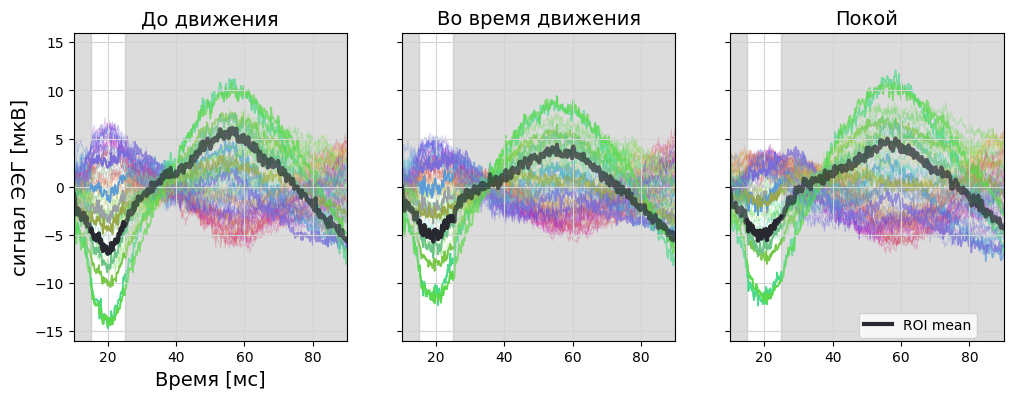

In [28]:
# tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 3, figsize=(12, 4), sharex=True, sharey=True)

amp = 16
tmin, tmax = 10, 90

tlim = 15, 25

ROI_N20 = ["FCz", "Cz", "CPz", "FC2", "C2", "CP2", "C4", "CP4"]
plot_butterfly(epochs_avr[0], tmin, tmax, tlim, amp, ROI_N20, ax[0], xlabel="Время [мс]", ylabel="сигнал ЭЭГ [мкВ]", title="До движения")
plot_butterfly(epochs_avr[1], tmin, tmax, tlim, amp, ROI_N20, ax[1], xlabel="", ylabel="", title="Во время движения")
plot_butterfly(epochs_avr[2], tmin, tmax, tlim, amp, ROI_N20, ax[2], xlabel="", ylabel="", title="Покой")

handles, labels = ax[2].get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax[2].legend(handles, labels, loc=[.47, 0.01], frameon=True, fancybox=True)

fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1r_avg_{tlim}.png")
plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

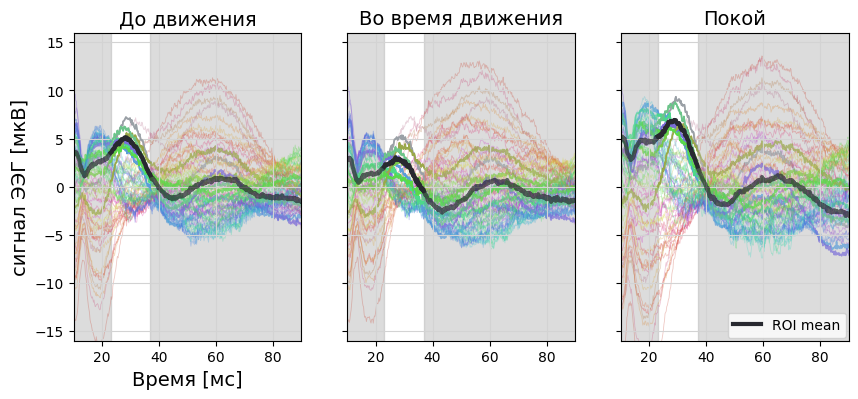

In [225]:
# tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

amp = 16
tmin, tmax = 10, 90

tlim = 23, 37
ROI_ipsi = ["FCz", "Cz", "CPz", "FC2", "C2", "CP2", "C4", "CP4"]

teps_av_am = np.mean(TEPs[[1, 2], :, :, :], axis=0)
plot_butterfly(teps_av_am[0], tmin, tmax, tlim, amp, ROI_ipsi, ax[0], xlabel="Время [мс]", ylabel="сигнал ЭЭГ [мкВ]", title="До движения")
plot_butterfly(teps_av_am[1], tmin, tmax, tlim, amp, ROI_ipsi, ax[1], xlabel="", ylabel="", title="Во время движения")
plot_butterfly(teps_av_am[2], tmin, tmax, tlim, amp, ROI_ipsi, ax[2], xlabel="", ylabel="", title="Покой")

handles, labels = ax[2].get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax[2].legend(handles, labels, loc=[.47, 0.01], frameon=True, fancybox=True)

fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_{tlim}.png")
plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

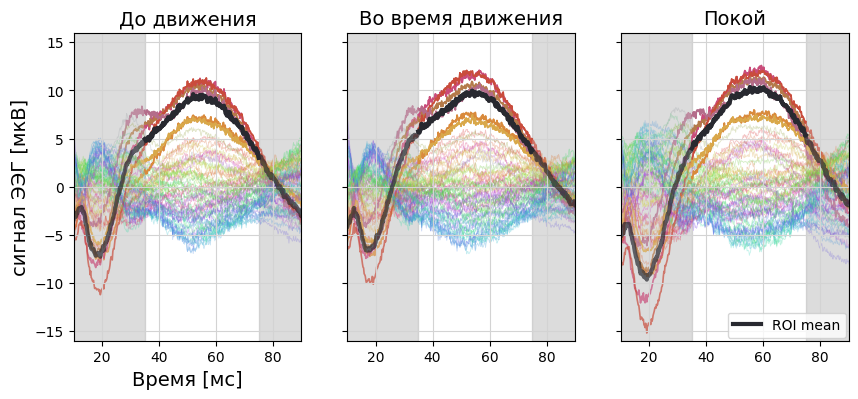

In [215]:
# tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

amp = 16
tmin, tmax = 10, 90

tlim = 35, 75

plot_butterfly(epochs_avr[0], tmin, tmax, tlim, amp, ROI_P60, ax[0], xlabel="Время [мс]", ylabel="сигнал ЭЭГ [мкВ]", title="До движения")
plot_butterfly(epochs_avr[1], tmin, tmax, tlim, amp, ROI_P60, ax[1], xlabel="", ylabel="", title="Во время движения")
plot_butterfly(epochs_avr[2], tmin, tmax, tlim, amp, ROI_P60, ax[2], xlabel="", ylabel="", title="Покой")

handles, labels = ax[2].get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax[2].legend(handles, labels, loc=[.47, 0.01], frameon=True, fancybox=True)
fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_{tlim}.png")
plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

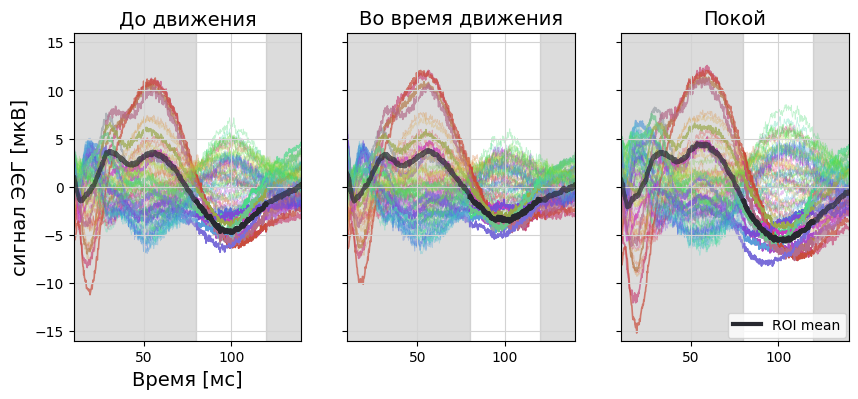

In [216]:
# tep_avg_all = np.mean(epochs_avr, axis=0)
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharex=True, sharey=True)

amp = 16
tmin, tmax = 10, 140

tlim = 80, 120

ROI_100 = [ "C3", "C1", "CP3",  "CP1", "FC3", "FC1", "FCz", "Cz", "CPz", "FC2", "C2", "C4", "F1", "Fz"]
# ROI_100 = [ "FCz"]
plot_butterfly(epochs_avr[0], tmin, tmax, tlim, amp, ROI_100, ax[0], xlabel="Время [мс]", ylabel="сигнал ЭЭГ [мкВ]", title="До движения")
plot_butterfly(epochs_avr[1], tmin, tmax, tlim, amp, ROI_100, ax[1], xlabel="", ylabel="", title="Во время движения")
plot_butterfly(epochs_avr[2], tmin, tmax, tlim, amp, ROI_100, ax[2], xlabel="", ylabel="", title="Покой")

handles, labels = ax[2].get_legend_handles_labels()
filtered = [(h, l) for h, l in zip(handles, labels) if l is not None]
if filtered:
    handles, labels = zip(*filtered)
    ax[2].legend(handles, labels, loc=[.47, 0.01], frameon=True, fancybox=True)
fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_{tlim}.png")
plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

# topoplots

# topoplots

In [30]:
from matplotlib import colormaps as cm
from matplotlib.colors import ListedColormap
viridisBig = cm.get_cmap('jet')
newcmp = 'jet' #ListedColormap(viridisBig(np.linspace(0, 1, 35)))

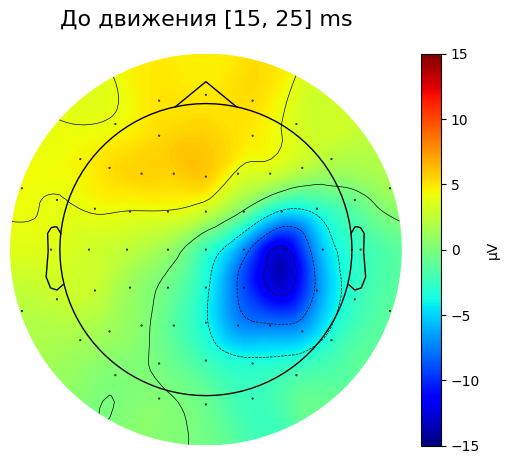

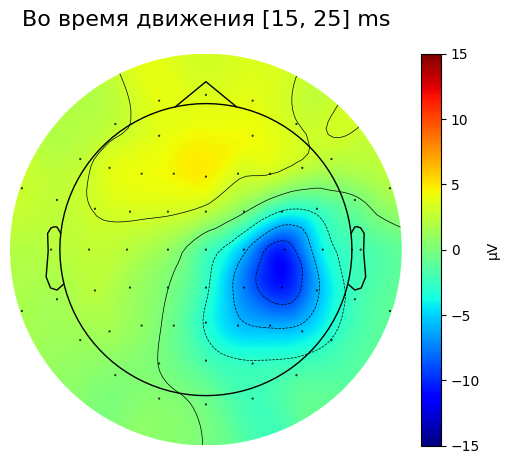

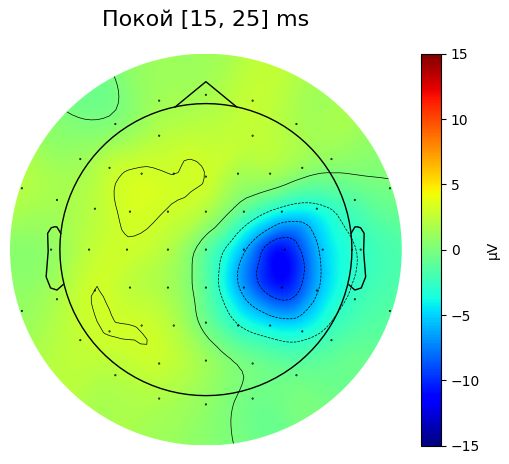

In [32]:
tlim = [15, 25] # N20
# tlim = [35, 75] # P60
# tlim = [23, 37] # P30



mask = get_mask(tlim, tvec)[0]
amp = 15
epochs_peak = np.mean(epochs_avr[:, mask, :], axis=1)

 #P30
# teps_av_am = np.mean(TEPs[[1, 2], :, :, :], axis=0)
# epochs_peak = np.mean(teps_av_am[:, mask, :], axis=1)

titles = ["До движения", "Во время движения", "Покой"]
for i in [0, 1, 2]:
    im, cn = plot_topomap(epochs_peak[i], positions,  ch_type='eeg',image_interp='cubic',  #names = ch_labels,axes=axis[j], 
                    size=5, show=False, contours=5, sphere=0.5, cmap=newcmp, extrapolate='head', vlim=[-amp, amp])

    cbar = plt.colorbar(im,  fraction=0.05, aspect=20) #ax=axis[j],
    cbar.set_label('μV', fontsize=10)

    plt.title(f"{titles[i]} {tlim} ms", y=1.05, fontsize=16)
    fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1r_topoplot_{titles[i]}_{tlim}.png")
    plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

In [221]:
get_mask(tlim, tvec)

(array([1076, 1077, 1078, 1079, 1080, 1081, 1082, 1083, 1084, 1085, 1086,
        1087, 1088, 1089, 1090, 1091, 1092, 1093, 1094, 1095, 1096, 1097,
        1098, 1099, 1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108,
        1109, 1110, 1111, 1112, 1113, 1114, 1115, 1116, 1117, 1118, 1119,
        1120, 1121, 1122, 1123, 1124]),
 np.int64(1075))

In [39]:
epochs_peak.shape

(49, 64)

In [35]:
epochs_avr.shape

(3, 3501, 64)

In [30]:
epochs_avr.shape

(3, 3501, 64)

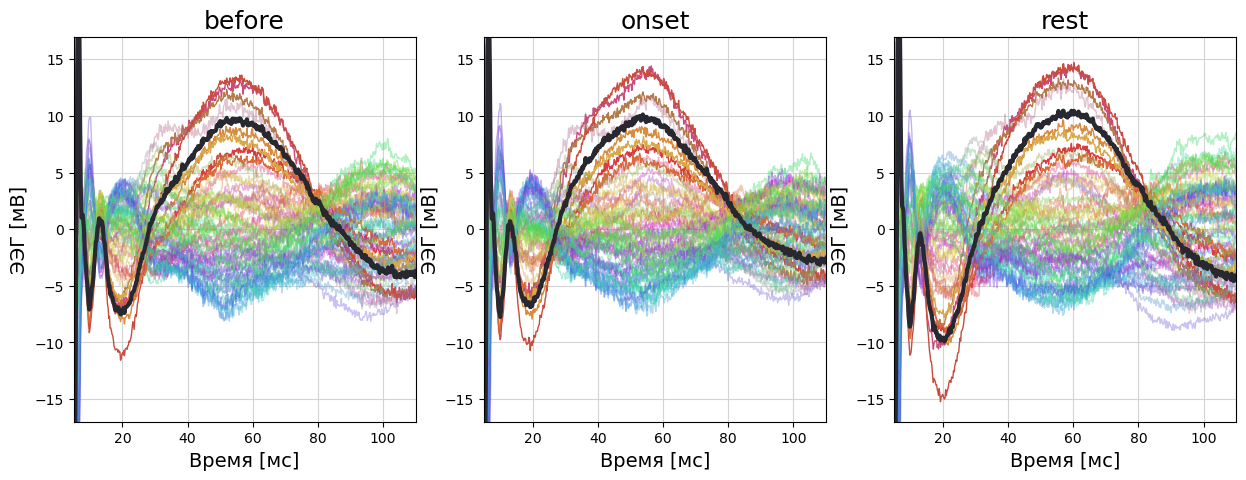

In [105]:
tmin, tmax = 5, 110
amp = 17
# N20!!!!!!!!!!!!!!!!!!!
titles = ["before", "onset", "rest"]
fig, axis = plt.subplots(1, 3, figsize=(15, 5))

ROI_contra = ["C3", "CP3", "CP5", "CP1", "P5", "P3", "P1"]
ROI_idx = [find_ch_idx(ch, CED_FILE) for ch in ROI_contra]

alpha= np.array([0.4] * epochs_avr.shape[2])
alpha[ROI_idx] = 1

for i in [0, 1, 2]:
    ax = axis[i]
    
    ch = 0
    for color, TEP in zip(colors, epochs_avr[i].T): # начало движения
        ax.plot(tvec, TEP, color=color, alpha=alpha[ch], linewidth=1)
        ch += 1
    
    roi_tep = np.mean(epochs_avr[i, :, ROI_idx], axis=0)
    ax.plot(tvec, roi_tep, color="#282930", alpha=1, linewidth=3)
    
    ax.set_xlim(tmin, tmax)
    ax.set_ylim(-amp, amp)
    # ax.set_ylim(0.45, 0.60)
    ax.set_xlabel("Время [мс]", fontsize=14)
    ax.set_ylabel("ЭЭГ [мВ]", fontsize=14)
    ax.grid(color="lightgrey")

    ax.set_title(titles[i], fontsize=18)

    ax.axvline(0, color="black", linewidth=2)

# fig.suptitle(f"Среднее по М1 РА")
# fig_filename = os.path.join(r"../results/fig16.04", f"teps_m1_avg_n20.png")
# plt.savefig(fig_filename, dpi=300, bbox_inches="tight")

In [ ]:
np.mean(epochs_avr[i, :, ROI_idx], axis=0).shape

(3501,)

In [88]:
epochs_avr[i, :, ROI_idx].shape

(7, 3501)

In [ ]:
# расчёты: 
# + скачать табличку - сессия, сет, задача, человек
# + находить записи одного типа
# усреднение записей по человеку с одной задачей (тоже сохранить?)
# нахождение пика для группы электродов в выделенном временном диапазоне
# определение для пика амплитуды, длительности, латентности
#

# визуализация: 
# бабочный график
# выделение на нём пика для группы электродов в выделенном временном диапазоне
# отрисовка топоплота
# отрисовка "статистики" (распределение/боксы) для амплитуды, длительности, латентности 

In [16]:
import h5py
def read_matlab_strings_correct(filepath, var_name):
    """Правильное чтение MATLAB string (новый тип) из .mat v7.3"""
    with File(filepath, 'r') as f:
        data = f["cleanedResult"][var_name]
        
        # MATLAB string хранится как dataset с атрибутами
        # или как массив ссылок на объекты с данными
        if data.dtype == np.dtype('O'):  # объектные ссылки
            strings = []
            # Проходим по всем элементам
            for idx in range(data.size):
                ref = data.flatten()[idx]
                if isinstance(ref, h5py.h5r.Reference):
                    # Получаем объект по ссылке
                    str_obj = f[ref]
                    # Читаем данные как байты
                    raw_data = str_obj[()]
                    
                    # MATLAB строки обычно UTF-16
                    if raw_data.dtype == np.uint16:
                        # Конвертируем числа в символы
                        chars = raw_data.flatten()
                        # Убираем нулевые символы в конце
                        chars = chars[chars != 0]
                        s = ''.join(chr(c) for c in chars)
                    elif raw_data.dtype == np.uint8:
                        s = raw_data.tobytes().decode('utf-8', errors='ignore')
                    else:
                        s = str(raw_data)
                    
                    strings.append(s)
                else:
                    strings.append(str(ref))
            
            # Если исходные данные были 2D, восстанавливаем форму
            if len(data.shape) == 2:
                strings = np.array(strings).reshape(data.shape)
            
            return strings
        else:
            return data[()]

# Использование
labels = read_matlab_strings_correct(filename, 'epoch_types')
print(labels)

[[3707764736          2          1          1          6          1]]


In [11]:
labels = read_mat73_variable(filename, 'epoch_types')
epochs = read_mat73_variable(filename, 'epochs_clean')

In [17]:
import hdf5storage
data = hdf5storage.loadmat(filename)

In [20]:
data["cleanedResult"]["epoch_types"]

array([[[3707764736,          2,          1,          1,          6,
                  1]]], dtype=uint32)